In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [ ]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
IMAGES_DIR = RAW_DIR / "SPAQ_small"

LABELS_PATH = RAW_DIR / "spaq_labels.csv"

if not LABELS_PATH.exists():
    csv_files = list(RAW_DIR.glob("*.csv"))

    if len(csv_files) != 1:
        raise FileNotFoundError(
            f"Не вдалося автоматично знайти CSV. Знайдено: {csv_files}"
        )

    LABELS_PATH = csv_files[0]

print("Фотографії:", IMAGES_DIR)
print("Таблиця:", LABELS_PATH)
print("Папка існує:", IMAGES_DIR.exists())
print("Таблиця існує:", LABELS_PATH.exists())

Фотографії: c:\Users\Admin\Desktop\PhotoAnalyser\data\raw\SPAQ_small
Таблиця: c:\Users\Admin\Desktop\PhotoAnalyser\data\raw\spaq_labels.csv
Папка існує: True
Таблиця існує: True


In [4]:
labels = pd.read_csv(LABELS_PATH)

print("Розмір початкової таблиці:", labels.shape)
print("Колонки:", labels.columns.tolist())

display(labels.head())

Розмір початкової таблиці: (11125, 7)
Колонки: ['Image name', 'MOS', 'Brightness', 'Colorfulness', 'Contrast', 'Noisiness', 'Sharpness']


,Image name,MOS,Brightness,Colorfulness,Contrast,Noisiness,Sharpness
0,00001.jpg,48.86,47.43,55.57,55.71,37.86,42.57
1,00002.jpg,62.50,55.38,67.13,53.13,57.50,47.50
2,00003.jpg,77.25,62.38,72.63,65.75,72.25,82.71
3,00004.jpg,67.00,68.43,69.43,67.00,67.86,63.29
4,00005.jpg,22.71,54.29,62.14,51.00,38.43,15.57


Очищення таблиці, перейменування колонок, приведення оцінок до числового типу

In [5]:
labels.columns = labels.columns.str.strip()

labels = labels.rename(
    columns={
        "Image name": "image_name",
        "MOS": "overall_quality",
        "Brightness": "brightness_quality",
        "Colorfulness": "colorfulness_quality",
        "Contrast": "contrast_quality",
        "Noisiness": "noise_quality",
        "Sharpness": "sharpness_quality",
    }
)

score_columns = [
    "overall_quality",
    "brightness_quality",
    "colorfulness_quality",
    "contrast_quality",
    "noise_quality",
    "sharpness_quality",
]

required_columns = ["image_name"] + score_columns

missing_columns = set(required_columns) - set(labels.columns)

if missing_columns:
    raise ValueError(f"У таблиці немає колонок: {missing_columns}")

display(labels.head())

,image_name,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality
0,00001.jpg,48.86,47.43,55.57,55.71,37.86,42.57
1,00002.jpg,62.50,55.38,67.13,53.13,57.50,47.50
2,00003.jpg,77.25,62.38,72.63,65.75,72.25,82.71
3,00004.jpg,67.00,68.43,69.43,67.00,67.86,63.29
4,00005.jpg,22.71,54.29,62.14,51.00,38.43,15.57


In [ ]:
labels["image_name"] = (
    labels["image_name"]
    .astype(str)
    .str.strip()
)

for column in score_columns:
    labels[column] = pd.to_numeric(
        labels[column],
        errors="coerce"
    )

print("Пропущені значення до очищення:")
display(labels[required_columns].isna().sum())

Пропущені значення до очищення:


image_name              0
overall_quality         0
brightness_quality      0
colorfulness_quality    0
contrast_quality        0
noise_quality           0
sharpness_quality       0
dtype: int64

Видалення дублікатів

In [7]:
exact_duplicates = labels.duplicated().sum()

print("Повністю однакових рядків:", exact_duplicates)

labels = labels.drop_duplicates().copy()

Повністю однакових рядків: 0


In [8]:
duplicate_names = labels[
    labels.duplicated(subset="image_name", keep=False)
]

print("Повторення назв фотографій:", len(duplicate_names))

if not duplicate_names.empty:
    display(duplicate_names.sort_values("image_name").head(20))

labels = labels.drop_duplicates(subset="image_name", keep="first").copy()

Повторення назв фотографій: 0


Видалення рядків з пропусками, перевірка діапазону оцінок (0–100)

In [9]:
rows_before = len(labels)

labels = labels.dropna(
    subset=["image_name"] + score_columns
).copy()

print("Видалено рядків із пропусками:", rows_before - len(labels))

Видалено рядків із пропусками: 0


In [10]:
for column in score_columns:
    invalid_values = ~labels[column].between(0, 100)

    print(
        column,
        "значень поза діапазоном 0–100:",
        invalid_values.sum()
    )

overall_quality значень поза діапазоном 0–100: 0
brightness_quality значень поза діапазоном 0–100: 0
colorfulness_quality значень поза діапазоном 0–100: 0
contrast_quality значень поза діапазоном 0–100: 0
noise_quality значень поза діапазоном 0–100: 0
sharpness_quality значень поза діапазоном 0–100: 0


Обробка зображень

In [11]:
image_paths = sorted(IMAGES_DIR.glob("*.jpg"))

print("Знайдено фотографій:", len(image_paths))

Знайдено фотографій: 11125


In [12]:
image_records = []
broken_images = []

for index, image_path in enumerate(image_paths, start=1):
    try:
        with Image.open(image_path) as image:
            width, height = image.size
            mode = image.mode
            image.verify()

        image_records.append({
            "image_name": image_path.name,
            "width": width,
            "height": height,
            "color_mode": mode,
        })

    except Exception as error:
        broken_images.append({
            "image_name": image_path.name,
            "error": str(error),
        })

    if index % 1000 == 0:
        print(f"Перевірено {index} фотографій")

Перевірено 1000 фотографій
Перевірено 2000 фотографій
Перевірено 3000 фотографій
Перевірено 4000 фотографій
Перевірено 5000 фотографій
Перевірено 6000 фотографій
Перевірено 7000 фотографій
Перевірено 8000 фотографій
Перевірено 9000 фотографій
Перевірено 10000 фотографій
Перевірено 11000 фотографій


In [13]:
image_info = pd.DataFrame(image_records)
broken_images = pd.DataFrame(broken_images)

print("Коректних фотографій:", len(image_info))
print("Пошкоджених фотографій:", len(broken_images))

if not broken_images.empty:
    display(broken_images.head())

Коректних фотографій: 11125
Пошкоджених фотографій: 0


In [14]:
display(
    image_info
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(10)
)

,width,height,count
17,512,384,4402
5,384,512,4207
16,512,383,500
4,383,512,493
10,512,288,467
1,288,512,389
0,256,512,115
6,385,512,112
3,380,512,100
9,512,256,73


In [15]:
table_names = set(labels["image_name"])
folder_names = set(image_info["image_name"])

missing_images = table_names - folder_names
images_without_labels = folder_names - table_names

print("Є в таблиці, але немає файла:", len(missing_images))
print("Є файл, але немає оцінки:", len(images_without_labels))

print("Приклади відсутніх файлів:", list(missing_images)[:10])
print("Приклади файлів без оцінок:", list(images_without_labels)[:10])

Є в таблиці, але немає файла: 0
Є файл, але немає оцінки: 0
Приклади відсутніх файлів: []
Приклади файлів без оцінок: []


Об'єднання даних (оцінки + зображення)

In [16]:
data = labels.merge(
    image_info,
    on="image_name",
    how="inner"
)

print("Підготовлено фотографій:", len(data))

display(data.head())

Підготовлено фотографій: 11125


,image_name,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality,width,height,color_mode
0,00001.jpg,48.86,47.43,55.57,55.71,37.86,42.57,512,384,RGB
1,00002.jpg,62.50,55.38,67.13,53.13,57.50,47.50,512,384,RGB
2,00003.jpg,77.25,62.38,72.63,65.75,72.25,82.71,512,384,RGB
3,00004.jpg,67.00,68.43,69.43,67.00,67.86,63.29,384,512,RGB
4,00005.jpg,22.71,54.29,62.14,51.00,38.43,15.57,384,512,RGB


In [17]:
display(
    data[score_columns]
    .describe()
    .round(2)
)

,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality
count,11125.00,11125.00,11125.00,11125.00,11125.00,11125.00
mean,50.32,56.00,60.45,57.28,53.00,47.05
std,20.90,16.81,15.33,16.24,18.37,24.23
min,2.00,0.20,2.60,0.60,1.60,0.67
25%,32.46,45.57,50.67,46.63,38.43,24.14
50%,50.20,57.60,61.86,58.33,53.00,47.50
75%,68.82,68.30,72.00,69.80,68.27,69.38
max,96.00,97.00,96.00,95.67,98.00,96.33


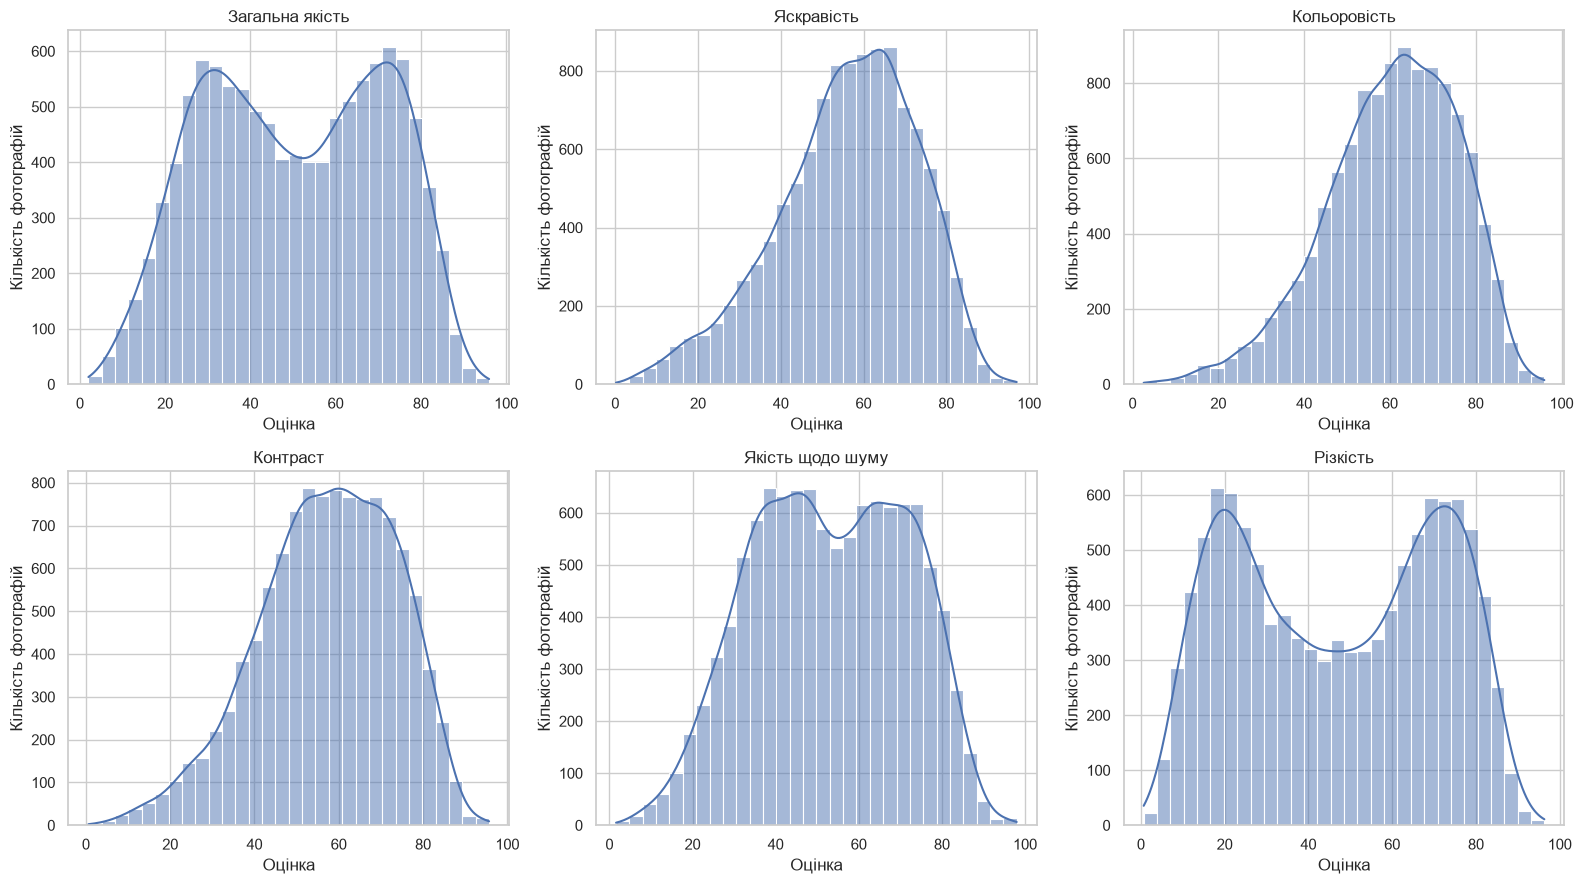

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

titles = {
    "overall_quality": "Загальна якість",
    "brightness_quality": "Яскравість",
    "colorfulness_quality": "Кольоровість",
    "contrast_quality": "Контраст",
    "noise_quality": "Якість щодо шуму",
    "sharpness_quality": "Різкість",
}

for ax, column in zip(axes, score_columns):
    sns.histplot(
        data=data,
        x=column,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(titles[column])
    ax.set_xlabel("Оцінка")
    ax.set_ylabel("Кількість фотографій")

plt.tight_layout()
plt.show()

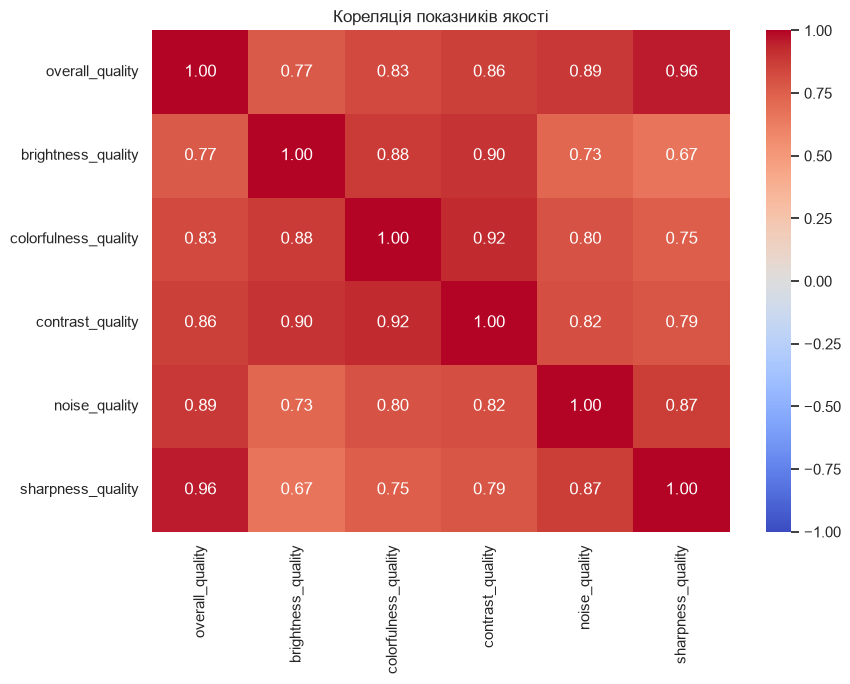

In [19]:
correlation = data[score_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Кореляція показників якості")
plt.tight_layout()
plt.show()

In [20]:
def show_examples(frame, title, count=5):
    fig, axes = plt.subplots(1, count, figsize=(16, 4))

    for ax, (_, row) in zip(axes, frame.head(count).iterrows()):
        image_path = IMAGES_DIR / row["image_name"]

        with Image.open(image_path) as image:
            ax.imshow(image.convert("RGB"))

        ax.set_title(
            f'{row["image_name"]}\n'
            f'MOS: {row["overall_quality"]:.1f}'
        )
        ax.axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

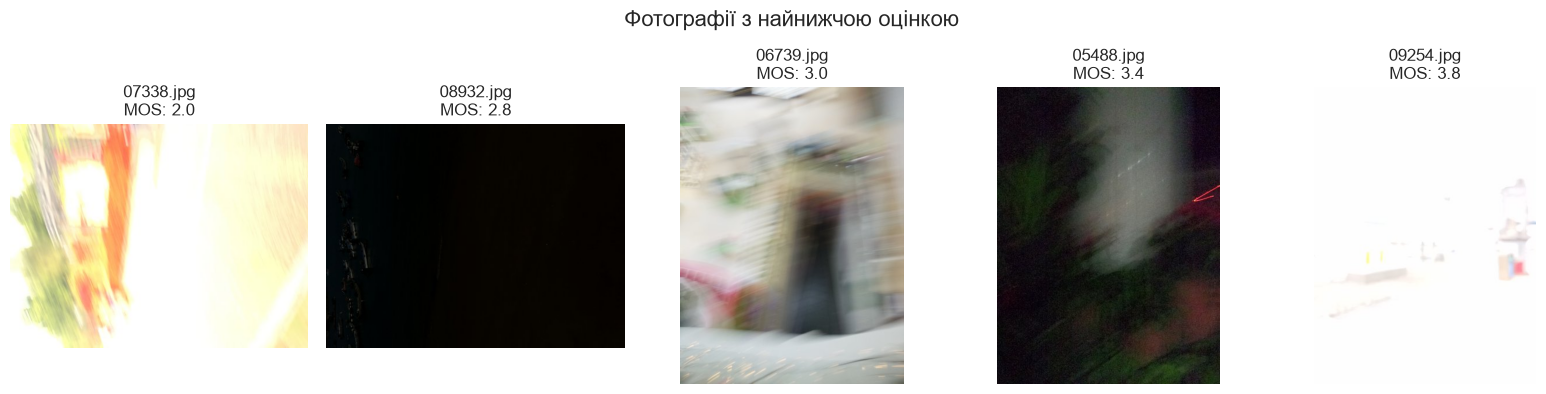

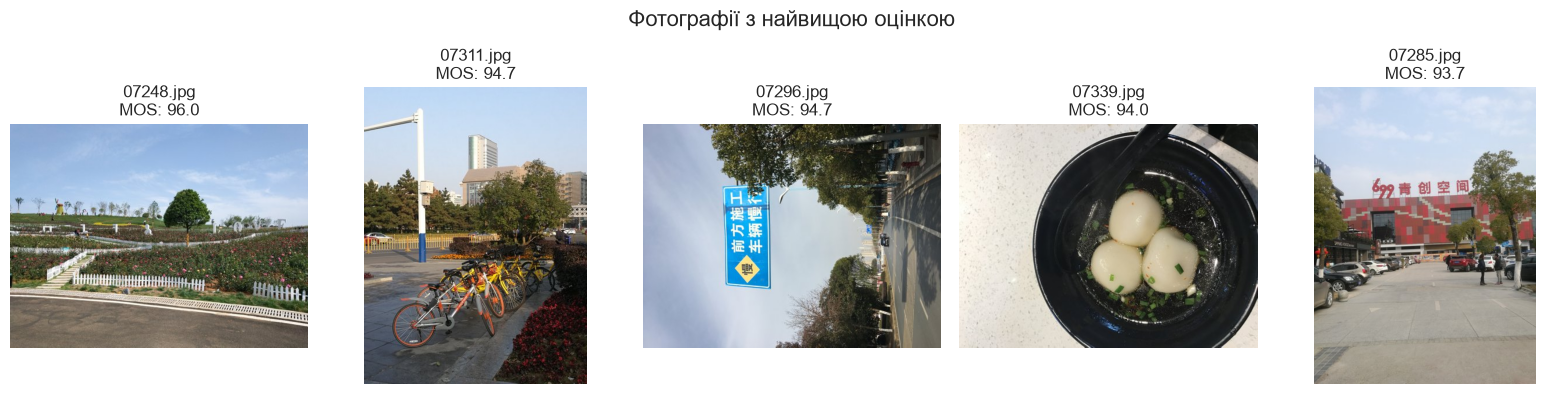

In [21]:
lowest_quality = data.sort_values("overall_quality")
highest_quality = data.sort_values(
    "overall_quality",
    ascending=False
)

show_examples(lowest_quality, "Фотографії з найнижчою оцінкою")
show_examples(highest_quality, "Фотографії з найвищою оцінкою")

Розбиття на train/val/test

In [22]:
data["quality_bin"] = pd.qcut(
    data["overall_quality"],
    q=10,
    labels=False,
    duplicates="drop"
)

display(
    data["quality_bin"]
    .value_counts()
    .sort_index()
)

quality_bin
0    1119
1    1108
2    1115
3    1109
4    1116
5    1112
6    1114
7    1109
8    1116
9    1107
Name: count, dtype: int64

In [23]:
train_data, temporary_data = train_test_split(
    data,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=data["quality_bin"]
)

validation_data, test_data = train_test_split(
    temporary_data,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temporary_data["quality_bin"]
)

train_data = train_data.copy()
validation_data = validation_data.copy()
test_data = test_data.copy()

train_data["split"] = "train"
validation_data["split"] = "validation"
test_data["split"] = "test"

In [24]:
manifest = pd.concat(
    [train_data, validation_data, test_data],
    ignore_index=True
)

manifest = manifest.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

print(manifest["split"].value_counts())

split
train         7787
test          1669
validation    1669
Name: count, dtype: int64


In [25]:
display(
    manifest
    .groupby("split")[score_columns]
    .mean()
    .round(2)
)

,overall_quality,brightness_quality,colorfulness_quality,contrast_quality,noise_quality,sharpness_quality
split,,,,,,
test,50.31,56.31,60.58,57.43,53.36,47.03
train,50.29,55.88,60.36,57.21,52.85,46.99
validation,50.45,56.29,60.77,57.50,53.34,47.31


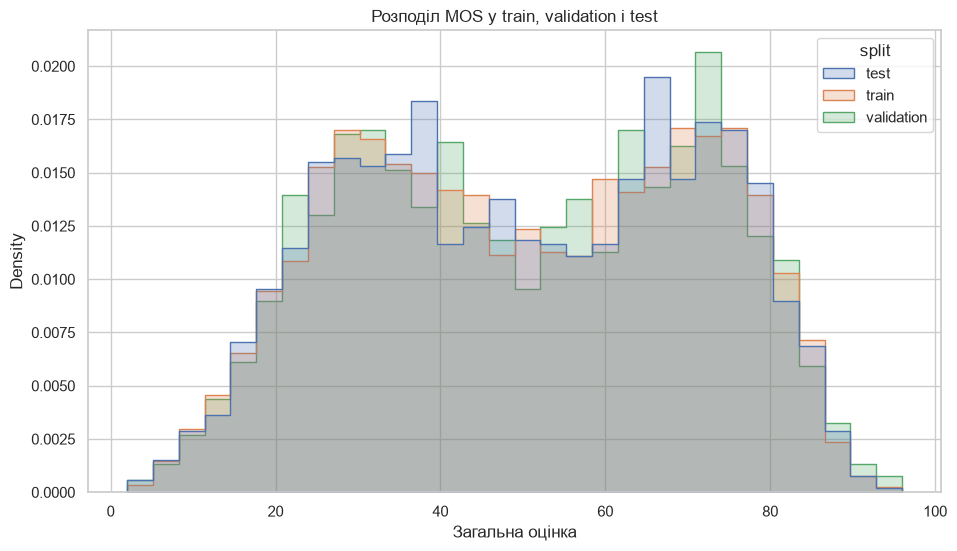

In [26]:
plt.figure(figsize=(11, 6))

sns.histplot(
    data=manifest,
    x="overall_quality",
    hue="split",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Розподіл MOS у train, validation і test")
plt.xlabel("Загальна оцінка")
plt.show()

In [27]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

manifest_path = PROCESSED_DIR / "dataset_manifest.csv"

manifest.to_csv(
    manifest_path,
    index=False
)

print("Збережено:", manifest_path)
print("Розмір:", manifest.shape)

Збережено: c:\Users\Admin\Desktop\PhotoAnalyser\data\processed\dataset_manifest.csv
Розмір: (11125, 12)
